**Word Embeddings Mini Projesi**

Amaç:

Bu proje, kelimelerin sayısal vektörler (embedding) ile temsil edilmesini ve bu vektörler üzerinden kelime benzerliklerini ve kelime bulutlarını görselleştirmeyi öğrenmek için yapılır.
TF-IDF veya N-Gram gibi klasik metin temsillerinden farklı olarak, Word Embeddings kelimelerin anlamsal ilişkilerini yakalar.
Kullanacağımız teknikler:
Word2Vec
GloVe (opsiyonel, hazır embedding)
FastText (opsiyonel, kelime köklerinden genelleme

In [6]:
!pip install gensim wordcloud nltk --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Kelime 'good' benzerleri: [('decent', 0.746442973613739), ('welldone', 0.7392721176147461), ('admirable', 0.7319826483726501), ('fine', 0.7302319407463074), ('passable', 0.725888192653656), ('unknowns', 0.7243620157241821), ('soso', 0.7233870029449463), ('dismal', 0.721721887588501), ('imo', 0.717109203338623), ('acceptable', 0.7157129645347595)]


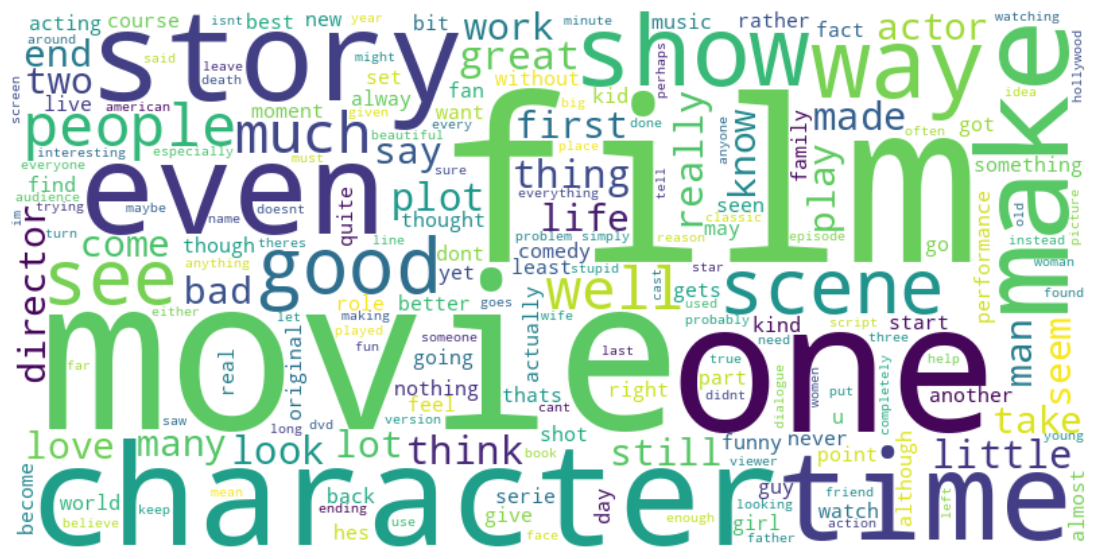

In [7]:
# 🔹 Kütüphaneler
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Stopwords indir
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 🔹 Dataset
df = pd.read_csv("/content/IMDB Dataset.csv", engine='python')
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})
df_small = df.sample(10000, random_state=42)  # hızlı prototip

# 🔹 Temizleme ve Tokenizasyon
def clean_and_tokenize(text):
    text = re.sub(r'<.*?>', ' ', text)  # HTML temizle
    text = text.lower()                  # küçük harfe çevir
    text = re.sub(r'[^a-z\s]', '', text) # noktalama temizle
    tokens = [word for word in text.split() if word not in stop_words] # stopwords çıkar
    return tokens

df_small['tokens'] = df_small['review'].apply(clean_and_tokenize)

# 🔹 Word2Vec Eğitimi
w2v_model = Word2Vec(sentences=df_small['tokens'], vector_size=100, window=5, min_count=2, workers=4, sg=1)

# 🔹 Kelime benzerlikleri
similar_words = w2v_model.wv.most_similar('good', topn=10)
print("Kelime 'good' benzerleri:", similar_words)

# 🔹 WordCloud görselleştirme
all_words = [word for tokens in df_small['tokens'] for word in tokens]
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()